In [ ]:
import numpy as np
from matplotlib import pyplot as plt

def FTCS(Qnj, Qnjforward, Qnjbackward, dt, dx, u, a):
    Qnforwardj = Qnj - (dt / dx) * u * (Qnj - Qnjbackward) + (dt / dx**2) * a * (Qnjforward - 2 * Qnj + Qnjbackward)
    return Qnforwardj

def plot(Q, T, numTs, Lx, numXs):
    fig = plt.figure(figsize = (10, 5))
    fig.suptitle('Solução da equação de advecção-difusão', fontsize = 16)

    # Plot 3D
    ax = fig.add_subplot(1, 1, 1, projection = '3d')
    x = np.linspace(0, Lx, numXs)
    t = np.linspace(0, T, numTs)
    X, T = np.meshgrid(x, t)
    
    surf = ax.plot_surface(X, T, Q, cmap = 'viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('c(x,t)')

    plt.show()
    
    

def apply(function, T, numTs, Lx, numXs, u, a, ce, c0, ignore_stability = False):
    if (u == 0 and a == 0):
        print("Velocidade de advecção (u) e o coeficiente de difusão (a) não podem ser nulos simultaneamente.")
        return -1
    elif (u == 0):
        print("u = 0. Regime puramente difusivo.")
    elif (a == 0):
        print("a = 0. Regime puramente advectivo.")
    elif (u < 0):
        print("Velocidade de advecção (u) deve ser maior ou igual a zero.")
        return -1

    dt = T/numTs
    dx = Lx/numXs

    dtmax = dx**2 / (u * dx + 2 * a)
    if (dt > dtmax):
        if (not ignore_stability):
            print(f"Δt = {dt} > Δtmax = {dtmax}. \nAumente o número de partições temporais (nt) ou desative a verificação de estabilidade.")
            return -1
        else:
            print(f"Δt = {dt} > Δtmax = {dtmax}. \nA solução pode não ser estável.")

    Q = np.zeros((numTs, numXs))

    # Condições iniciais
    Q[:, 0] = ce # c(x=0, t) = ca
    Q[0, :] = c0 # c(x, t=0) = cb

    for n in range(0, numTs-1):
        for j in range(1, numXs-1):
            Q[n+1, j] = function(Q[n, j], Q[n, j+1], Q[n, j-1], dt, dx, u, a)

        # Condição de contorno de saída com aproximação recuada de 1ª ordem
        Q[n+1, -1] = Q[n+1, -2]

    plot(Q, T, numTs, Lx, numXs)

    return Q


a = 0. Regime puramente advectivo.


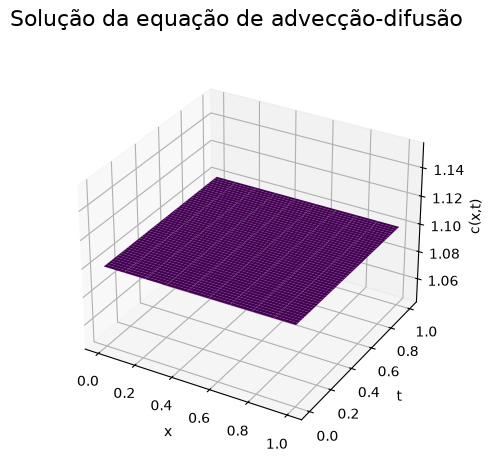

In [ ]:
def main():
    # Malha
    Lx = 1.0
    nx = 10
    T = 1.0
    nt = 1000
    ignore_stability = False

    # Constantes
    u = 2.0
    a = 0

    # Condição inicial
    c0 = 1.1

    # Condição de contorno de entrada
    ce = 1.1

    apply(FTCS, T, nt, Lx, nx, u, a, ce, c0, ignore_stability)

main()
